In [195]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [196]:
# Đọc file Excel
df = pd.read_excel('/content/MobilePhone.xlsx')

In [197]:
df.sample(n=10)

,phone_brand,phone_model,store,price,currency,price_USD,storage,ram,Launch,Dimensions,...,Chipset,CPU,GPU,Year,Foldable,PPI_Density,quantile_10,quantile_50,quantile_90,price_range
1044,nokia,Nokia X30,Amazon US,529.00,USD,529.00,256,8,2022-09-21,158.9 x 73.9 x 8 mm (6.26 x 2.91 x 0.31 in),...,Qualcomm SM6375 Snapdragon 695 5G (6 nm),Octa-core (2x2.2 GHz Kryo 660 Gold & 6x1.7 GHz...,Adreno 619,2022.0,0.0,409.0,114.99,247.18,793.20,medium price
1279,nokia,Nokia X30,AliExpress,279.89,USD,279.89,256,8,2022-09-21,158.9 x 73.9 x 8 mm (6.26 x 2.91 x 0.31 in),...,Qualcomm SM6375 Snapdragon 695 5G (6 nm),Octa-core (2x2.2 GHz Kryo 660 Gold & 6x1.7 GHz...,Adreno 619,2022.0,0.0,409.0,114.99,247.18,793.20,medium price
327,xiaomi,Xiaomi Mi 10 5G,Amazon DE,319.99,EUR,346.74,256,8,2020-02-14,162.5 x 74.8 x 9 mm (6.40 x 2.94 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,realme,8,Amazon DE,379.99,EUR,411.76,512,12,2024-05-28,162 x 75.1 x 8.7 mm (6.38 x 2.96 x 0.34 in),...,Qualcomm SM7675 Snapdragon 7+ Gen 3 (4 nm),Octa-core (1x2.8 GHz Cortex-X4 & 4x2.6 GHz Cor...,Adreno 732,2024.0,0.0,450.0,161756.00,552385.00,1380286.00,medium price
287,xiaomi,Xiaomi Poco M6 Pro,AliExpress,174.49,USD,174.49,512,12,2024-01-12,161.1 x 75 x 8 mm (6.34 x 2.95 x 0.31 in),...,Mediatek Helio G99 Ultra,Octa-core (2x2.2 GHz Cortex-A76 & 6x2.0 GHz Co...,Mali-G57 MC2,2024.0,0.0,395.0,161756.00,552385.00,1380286.00,medium price
233,samsung,Samsung Galaxy A55,Amazon UK,480.03,GBP,624.52,256,12,2024-03-15,161.1 x 77.4 x 8.2 mm (6.34 x 3.05 x 0.32 in),...,Exynos 1480 (4 nm),Octa-core (4x2.75 GHz Cortex-A78 & 4x2.0 GHz C...,Xclipse 530,2024.0,0.0,390.0,161756.00,552385.00,1380286.00,medium price
683,realme,Realme GT Neo2,Amazon UK,441.26,GBP,574.08,256,8,2021-09-28,162.9 x 75.8 x 9 mm (6.41 x 2.98 x 0.35 in),...,Qualcomm SM8250-AC Snapdragon 870 5G (7 nm),Octa-core (1x3.2 GHz Kryo 585 & 3x2.42 GHz Kry...,Adreno 650,2021.0,0.0,398.0,127.50,249.99,584.15,medium price
1344,nokia,Nokia C32,Amazon DE,109.99,EUR,119.19,128,4,2023-02-25,164.6 x 75.9 x 8.6 mm (6.48 x 2.99 x 0.34 in),...,Unisoc SC9863A1 (22 nm),Octa-core (4x1.6 GHz Cortex-A55 & 4x1.2 GHz Co...,IMG8322,2023.0,0.0,270.0,118913.00,330675.00,999.99,medium price
1421,xiaomi,Xiaomi 13T Pro,Amazon DE,1352.20,EUR,1465.24,1000,16,2023-09-26,162.2 x 75.7 x 8.5 mm (6.39 x 2.98 x 0.33 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
138,samsung,Samsung Galaxy S24 Ultra,Samsung,1219.99,USD,1219.99,1000,12,2024-01-24,162.3 x 79 x 8.6 mm (6.39 x 3.11 x 0.34 in),...,Qualcomm SM8650-AC Snapdragon 8 Gen 3 (4 nm),8-core (1x3.39GHz Cortex-X4 & 3x3.1GHz Cortex-...,Adreno 750 (1 GHz),2024.0,0.0,505.0,161756.00,552385.00,1380286.00,medium price


In [198]:
# Hiển thị 5 dòng đầu
df.head()

,phone_brand,phone_model,store,price,currency,price_USD,storage,ram,Launch,Dimensions,...,Chipset,CPU,GPU,Year,Foldable,PPI_Density,quantile_10,quantile_50,quantile_90,price_range
0,apple,Apple iPhone 16 Pro,Amazon DE,1256.99,EUR,1362.07,256,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),...,Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0,161756.0,552385.0,1380286.0,medium price
1,apple,Apple iPhone 16 Pro,Amazon DE,1381.99,EUR,1497.52,512,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),...,Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0,161756.0,552385.0,1380286.0,high price
2,apple,Apple iPhone 16 Pro,Amazon DE,1579.00,EUR,1711.00,1000,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),...,Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0,161756.0,552385.0,1380286.0,high price
3,apple,Apple iPhone 16 Pro Max,Amazon DE,1449.00,EUR,1570.14,512,8,2024-09-20,163 x 77.6 x 8.3 mm (6.42 x 3.06 x 0.33 in),...,Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0,161756.0,552385.0,1380286.0,high price
4,apple,Apple iPhone 16,Amazon DE,949.00,EUR,1028.34,256,8,2024-09-20,147.6 x 71.6 x 7.8 mm (5.81 x 2.82 x 0.31 in),...,Apple A18 (3 nm),Hexa-core (2x4.04 GHz + 4x2.20 GHz),Apple GPU (5-core graphics),2024.0,0.0,460.0,161756.0,552385.0,1380286.0,medium price


In [199]:
df. shape

(1715, 31)

In [200]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1715 entries, 0 to 1714
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   phone_brand         1715 non-null   object        
 1   phone_model         1715 non-null   object        
 2   store               1715 non-null   object        
 3   price               1715 non-null   float64       
 4   currency            1715 non-null   object        
 5   price_USD           1715 non-null   float64       
 6   storage             1715 non-null   int64         
 7   ram                 1715 non-null   int64         
 8   Launch              1715 non-null   datetime64[ns]
 9   Dimensions          1715 non-null   object        
 10  Weight              1712 non-null   float64       
 11  Display_Type        1715 non-null   object        
 12  Display_Size        1715 non-null   float64       
 13  Display_Resolution  1715 non-null   object      

#CHƯƠNG 4: XỬ LÝ DỮ LIỆU

#4.1. Tiền xử lý dữ liệu

4.1.1. Kiểm tra missing value

In [201]:
print('Kiểm tra missing value:')
display(df.isnull().sum())

Kiểm tra missing value:


,0
phone_brand,0
phone_model,0
store,0
price,0
currency,0
price_USD,0
storage,0
ram,0
Launch,0
Dimensions,0


In [202]:
# Xác định danh sách cột định lượng và định tính ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [203]:
if 'phone_brand' in numeric_cols:
    numeric_cols.remove('phone_brand')
if 'phone_brand' in categorical_cols:
    categorical_cols.remove('phone_brand')

In [204]:
# Xử lý cột định lượng: thay thế bằng mean theo từng phone_brand
for col in numeric_cols:
    if df[col].isnull().any():
        # Chỉ xử lý nếu cột có missing
        # Tính mean theo từng brand và lưu vào một Series
        brand_means = df.groupby('phone_brand')[col].transform('mean')
        # Thay thế NaN bằng giá trị mean tương ứng
        df[col] = df[col].fillna(brand_means)
        print(f"Đã xử lý cột '{col}' (định lượng): Thay thế bằng mean theo phone_brand.")

Đã xử lý cột 'Weight' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'NFC' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'BATTERY' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'Year' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'Foldable' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'PPI_Density' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'quantile_10' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'quantile_50' (định lượng): Thay thế bằng mean theo phone_brand.
Đã xử lý cột 'quantile_90' (định lượng): Thay thế bằng mean theo phone_brand.


In [205]:
# Xử lý cột định tính: thay thế bằng mode (giá trị xuất hiện nhiều nhất) theo từng phone_brand
for col in categorical_cols:
    if df[col].isnull().any():
        # Tính mode theo từng brand. Dùng .transform(lambda x: x.mode()[0] nếu có mode, else x)
        # Cần xử lý trường hợp một nhóm không có mode (toàn NaN)
        brand_modes = df.groupby('phone_brand')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
        # Thay thế NaN bằng giá trị mode tương ứng
        df[col] = df[col].fillna(brand_modes)
        print(f"Đã xử lý cột '{col}' (định tính): Thay thế bằng mode theo phone_brand.")

Đã xử lý cột 'USB' (định tính): Thay thế bằng mode theo phone_brand.
Đã xử lý cột 'Features_Sensors' (định tính): Thay thế bằng mode theo phone_brand.
Đã xử lý cột 'Colors' (định tính): Thay thế bằng mode theo phone_brand.
Đã xử lý cột 'Video' (định tính): Thay thế bằng mode theo phone_brand.
Đã xử lý cột 'Chipset' (định tính): Thay thế bằng mode theo phone_brand.
Đã xử lý cột 'CPU' (định tính): Thay thế bằng mode theo phone_brand.
Đã xử lý cột 'GPU' (định tính): Thay thế bằng mode theo phone_brand.
Đã xử lý cột 'price_range' (định tính): Thay thế bằng mode theo phone_brand.


In [206]:
#KIỂM TRA KẾT QUẢ ---
print("\n" + "="*50)
print("KẾT QUẢ SAU KHI XỬ LÝ")
print("="*50)
print(f"Số lượng missing values còn lại:\n{df.isnull().sum()}")
print(f"\nTổng số missing còn lại: {df.isnull().sum().sum()}")



KẾT QUẢ SAU KHI XỬ LÝ
Số lượng missing values còn lại:
phone_brand            0
phone_model            0
store                  0
price                  0
currency               0
price_USD              0
storage                0
ram                    0
Launch                 0
Dimensions             0
Weight                 0
Display_Type           0
Display_Size           0
Display_Resolution     0
OS                     0
NFC                    0
USB                    0
BATTERY                0
Features_Sensors       0
Colors                 0
Video                  0
Chipset               31
CPU                   31
GPU                   31
Year                  31
Foldable              31
PPI_Density           31
quantile_10           31
quantile_50           31
quantile_90           31
price_range           31
dtype: int64

Tổng số missing còn lại: 310


In [207]:
df[df.isna().any(axis=1)]

,phone_brand,phone_model,store,price,currency,price_USD,storage,ram,Launch,Dimensions,...,Chipset,CPU,GPU,Year,Foldable,PPI_Density,quantile_10,quantile_50,quantile_90,price_range
8,asus,Asus ROG Phone 8 Pro,Amazon DE,1199.99,EUR,1300.31,1000,24,2024-01-18,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,asus,Asus Zenfone 11 Ultra,Amazon DE,749.00,EUR,811.62,512,16,2024-04-14,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
110,asus,Asus ROG Phone 8,Amazon US,799.99,USD,799.99,256,16,2024-01-18,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111,asus,Asus ROG Phone 8 Pro,Amazon US,1054.00,USD,1054.00,1000,24,2024-01-18,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,asus,Asus Zenfone 11 Ultra,Amazon US,699.99,USD,699.99,512,16,2024-04-14,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191,asus,Asus ROG Phone 8,Amazon UK,917.90,GBP,1194.19,256,16,2024-01-18,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
192,asus,Asus ROG Phone 8 Pro,Amazon UK,687.50,GBP,894.44,1000,24,2024-01-18,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193,asus,Asus Zenfone 11 Ultra,Amazon UK,817.99,GBP,1064.20,512,16,2024-04-14,163.8 x 76.8 x 8.9 mm (6.45 x 3.02 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
447,asus,Asus Zenfone 8,Amazon DE,462.69,EUR,501.37,128,8,2021-05-13,148 x 68.5 x 8.9 mm (5.83 x 2.70 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
448,asus,Asus Zenfone 8,Amazon DE,375.13,EUR,406.49,256,8,2021-05-13,148 x 68.5 x 8.9 mm (5.83 x 2.70 x 0.35 in),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [208]:
df.dropna(inplace=True)
print(f"Kích thước DataFrame sau khi xóa các dòng có NaN: {df.shape}")

Kích thước DataFrame sau khi xóa các dòng có NaN: (1684, 31)


In [209]:
print('Kiểm tra lại missing value sau khi xóa:')
display(df.isnull().sum())

Kiểm tra lại missing value sau khi xóa:


,0
phone_brand,0
phone_model,0
store,0
price,0
currency,0
price_USD,0
storage,0
ram,0
Launch,0
Dimensions,0


4.1.2. Xử lý dữ liệu trùng lặp

In [210]:
df.duplicated().sum()

np.int64(0)

4.1.3. Chuẩn hóa dữ liệu

In [211]:
df['phone_brand'] = df['phone_brand'].str.lower()
print('Các giá trị duy nhất của phone_brand sau khi chuẩn hóa chữ thường:')
display(df['phone_brand'].unique())

Các giá trị duy nhất của phone_brand sau khi chuẩn hóa chữ thường:


array(['apple', 'google', 'honor', 'huawei', 'motorola', 'nothing',
       'oneplus', 'oppo', 'realme', 'samsung', 'sony', 'tcl', 'tecno',
       'vivo', 'xiaomi', 'zte', 'cubot', 'nokia', 'infinix', 'blackview',
       'htc'], dtype=object)

In [212]:
# loại bỏ khoảng trắng
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/tmp/ipykernel_91877/2568828933.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


4.1.4. Loại bỏ dữ liệu sai

In [213]:
# loại giá không hợp lệ
df = df[df['price'] > 0]

# loại dữ liệu bất hợp lý (ví dụ)
if 'ram' in df.columns:
    df = df[df['ram'] > 0]

if 'BATTERY' in df.columns:
    df = df[df['BATTERY'] > 0]

4.1.5. Kiểm tra tương quan

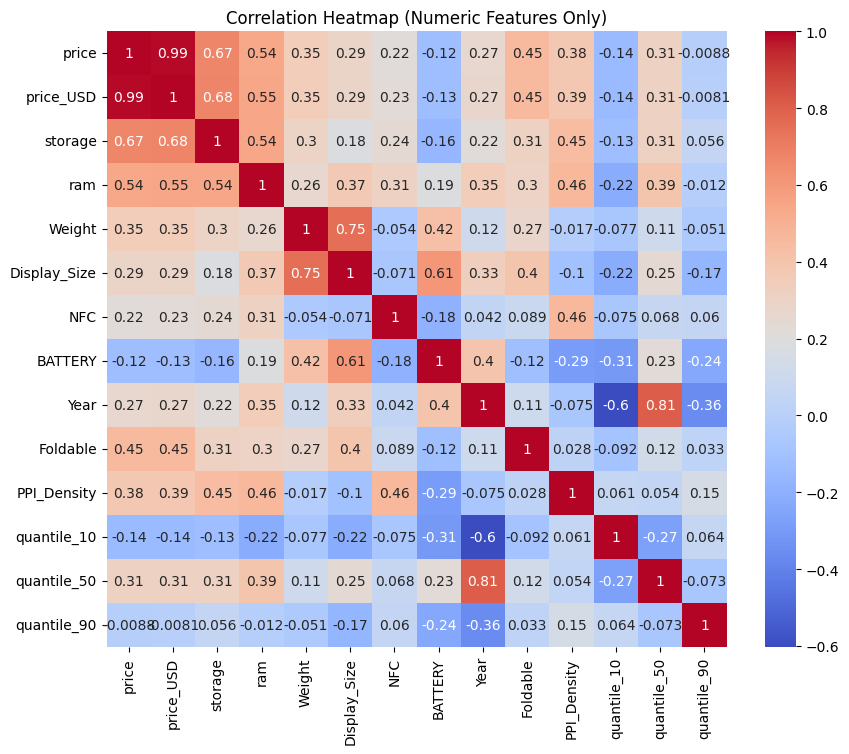

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chỉ lấy các cột số
num_df = df.select_dtypes(include=['int64', 'float64'])

# Tính correlation
corr = num_df.corr()

# Vẽ heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [215]:
corr['price'].sort_values(ascending=False)

,price
price,1.000000
price_USD,0.987617
storage,0.671182
ram,0.536670
Foldable,0.453302
PPI_Density,0.376311
Weight,0.347442
quantile_50,0.310040
Display_Size,0.289470
Year,0.266698


4.1.6. Loại bỏ biến

### Loại bỏ các biến không cần thiết

In [216]:
columns_to_drop = [
    'price_range',
    'price_USD',
    'currency',
    'quantile_10',
    'quantile_50',
    'quantile_90'
]

# Loại bỏ các cột nếu chúng tồn tại trong DataFrame
for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])
        print(f"Đã loại bỏ cột: {col}")

print("Kích thước DataFrame sau khi loại bỏ các cột:", df.shape)


Đã loại bỏ cột: price_range
Đã loại bỏ cột: price_USD
Đã loại bỏ cột: currency
Đã loại bỏ cột: quantile_10
Đã loại bỏ cột: quantile_50
Đã loại bỏ cột: quantile_90
Kích thước DataFrame sau khi loại bỏ các cột: (1684, 25)


In [217]:
display(df.head())

,phone_brand,phone_model,store,price,storage,ram,Launch,Dimensions,Weight,Display_Type,...,BATTERY,Features_Sensors,Colors,Video,Chipset,CPU,GPU,Year,Foldable,PPI_Density
0,apple,Apple iPhone 16 Pro,Amazon DE,1256.99,256,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),199.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,3582.0,"Face ID, accelerometer, gyro, proximity, compa...","Black Titanium, White Titanium, Natural Titani...","4K@24/25/30/60/100/120fps, 1080p@25/30/60/120/...",Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0
1,apple,Apple iPhone 16 Pro,Amazon DE,1381.99,512,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),199.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,3582.0,"Face ID, accelerometer, gyro, proximity, compa...","Black Titanium, White Titanium, Natural Titani...","4K@24/25/30/60/100/120fps, 1080p@25/30/60/120/...",Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0
2,apple,Apple iPhone 16 Pro,Amazon DE,1579.00,1000,8,2024-09-20,149.6 x 71.5 x 8.3 mm (5.89 x 2.81 x 0.33 in),199.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,3582.0,"Face ID, accelerometer, gyro, proximity, compa...","Black Titanium, White Titanium, Natural Titani...","4K@24/25/30/60/100/120fps, 1080p@25/30/60/120/...",Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0
3,apple,Apple iPhone 16 Pro Max,Amazon DE,1449.00,512,8,2024-09-20,163 x 77.6 x 8.3 mm (6.42 x 3.06 x 0.33 in),227.0,"LTPO Super Retina XDR OLED, 120Hz, HDR10, Dolb...",...,4685.0,"Face ID, accelerometer, gyro, proximity, compa...","Black Titanium, White Titanium, Natural Titani...","4K@24/25/30/60/100/120fps, 1080p@25/30/60/120/...",Apple A18 Pro (3 nm),Hexa-core (2x4.05 GHz + 4x2.42 GHz),Apple GPU (6-core graphics),2024.0,0.0,460.0
4,apple,Apple iPhone 16,Amazon DE,949.00,256,8,2024-09-20,147.6 x 71.6 x 7.8 mm (5.81 x 2.82 x 0.31 in),170.0,"Super Retina XDR OLED, HDR10, Dolby Vision, 10...",...,3561.0,"Face ID, accelerometer, gyro, proximity, compa...","Black, White, Pink, Teal, Ultramarine","4K@24/25/30/60fps, 1080p@25/30/60/120/240fps, ...",Apple A18 (3 nm),Hexa-core (2x4.04 GHz + 4x2.20 GHz),Apple GPU (5-core graphics),2024.0,0.0,460.0


In [218]:
# Định nghĩa các biến độc lập (X) và biến phụ thuộc (y)
y = df['price']
X = df.drop(columns=['price', 'phone_model', 'Launch']) # Loại bỏ 'price' và 'phone_model' cũng như 'Launch' khỏi X

#4.2. Phân tích dữ liệu (EDA)

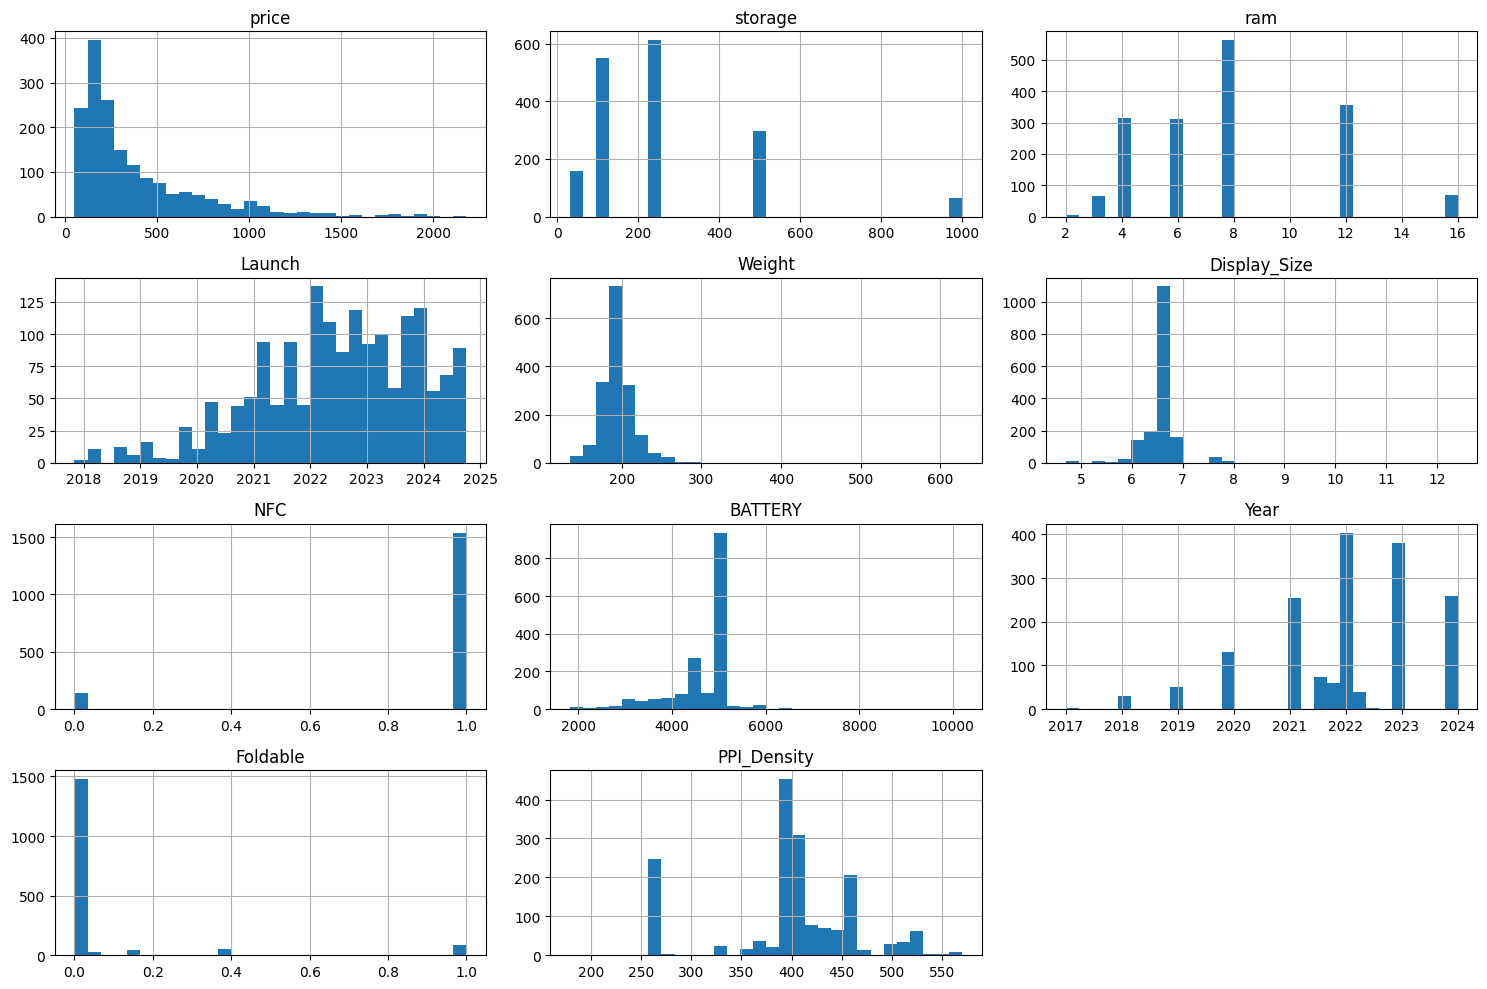

In [219]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

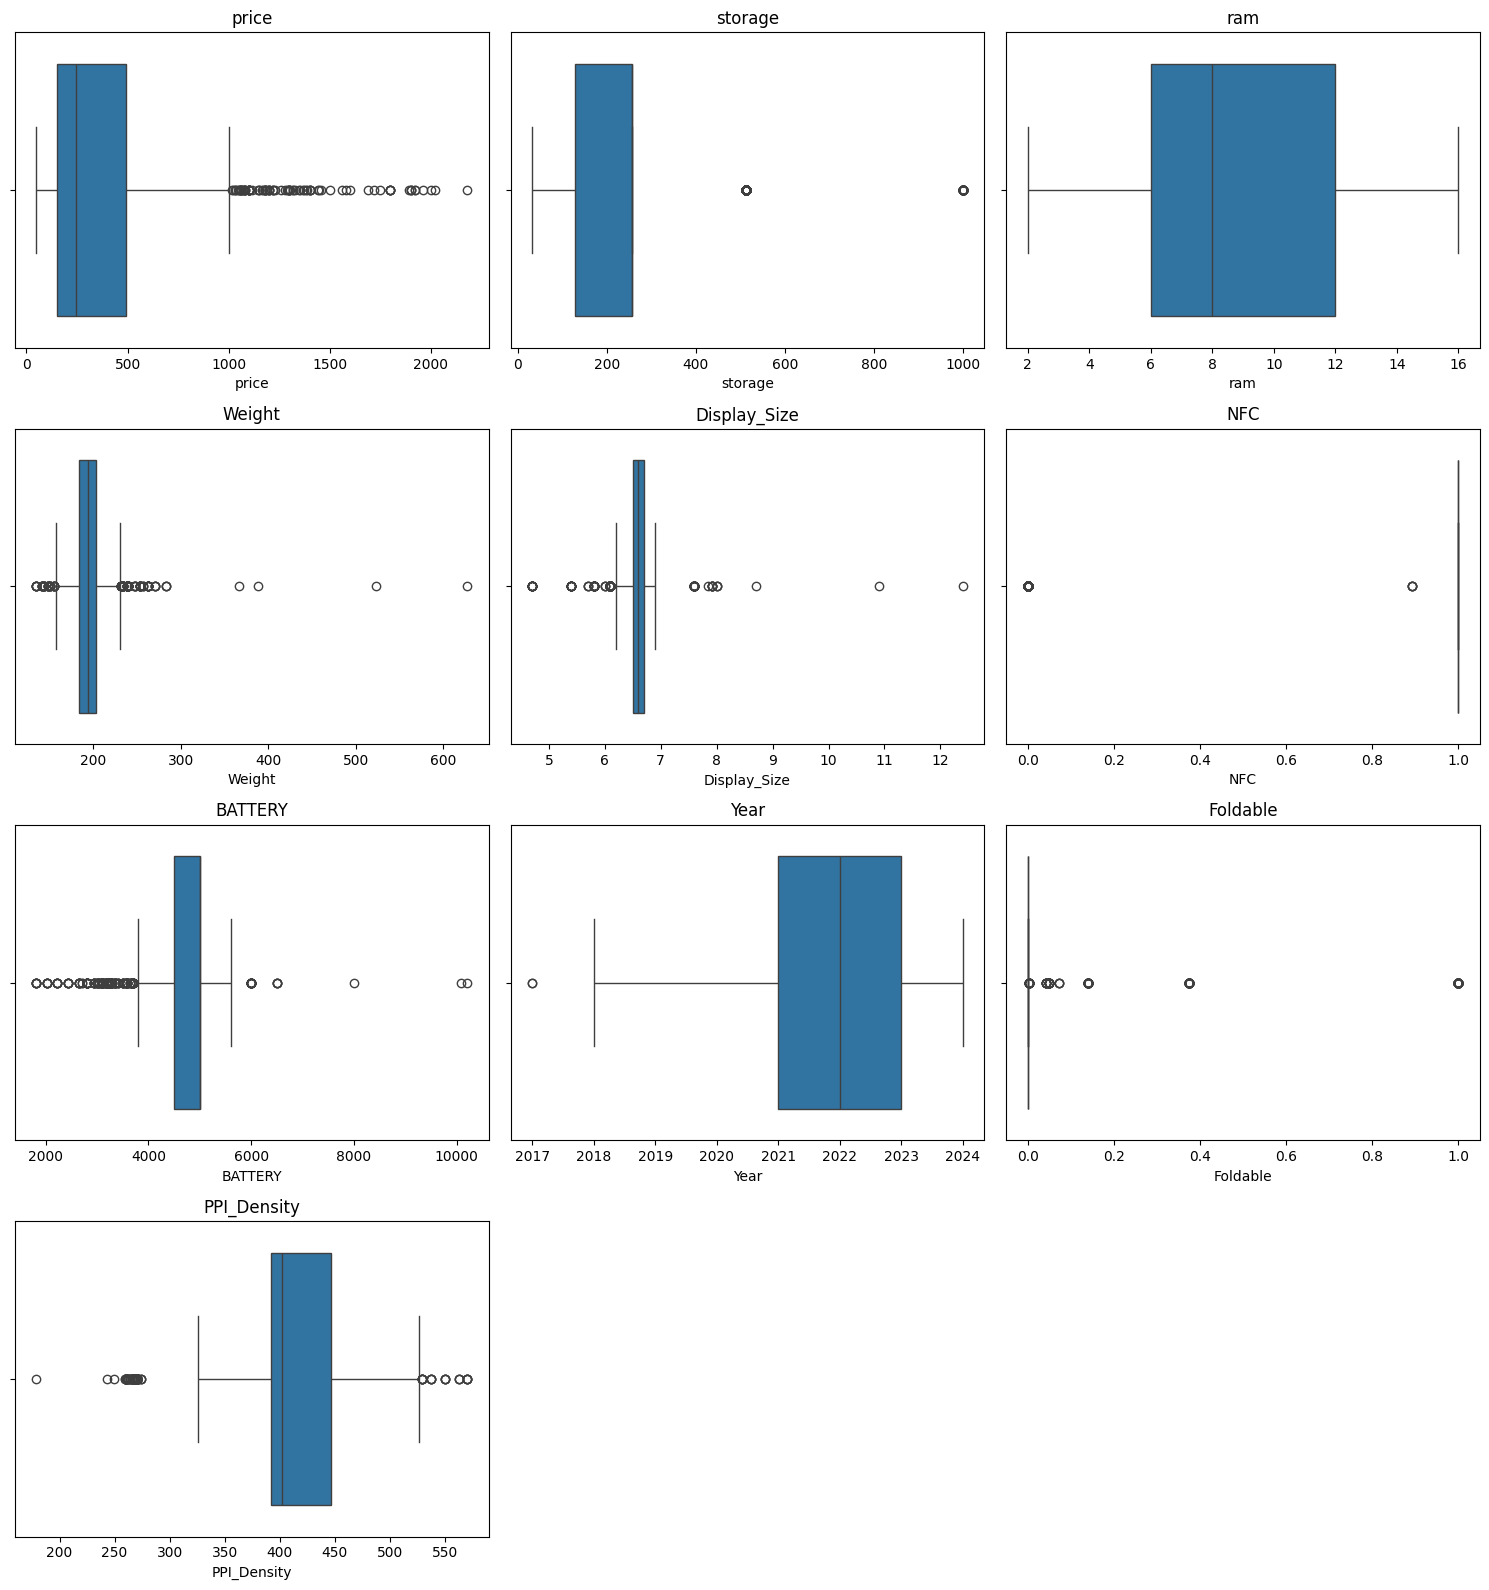

In [220]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Lấy các cột số
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Cấu hình subplot
n_cols = 3  # số biểu đồ mỗi hàng
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(5*n_cols, 4*n_rows))

# Vẽ từng boxplot
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

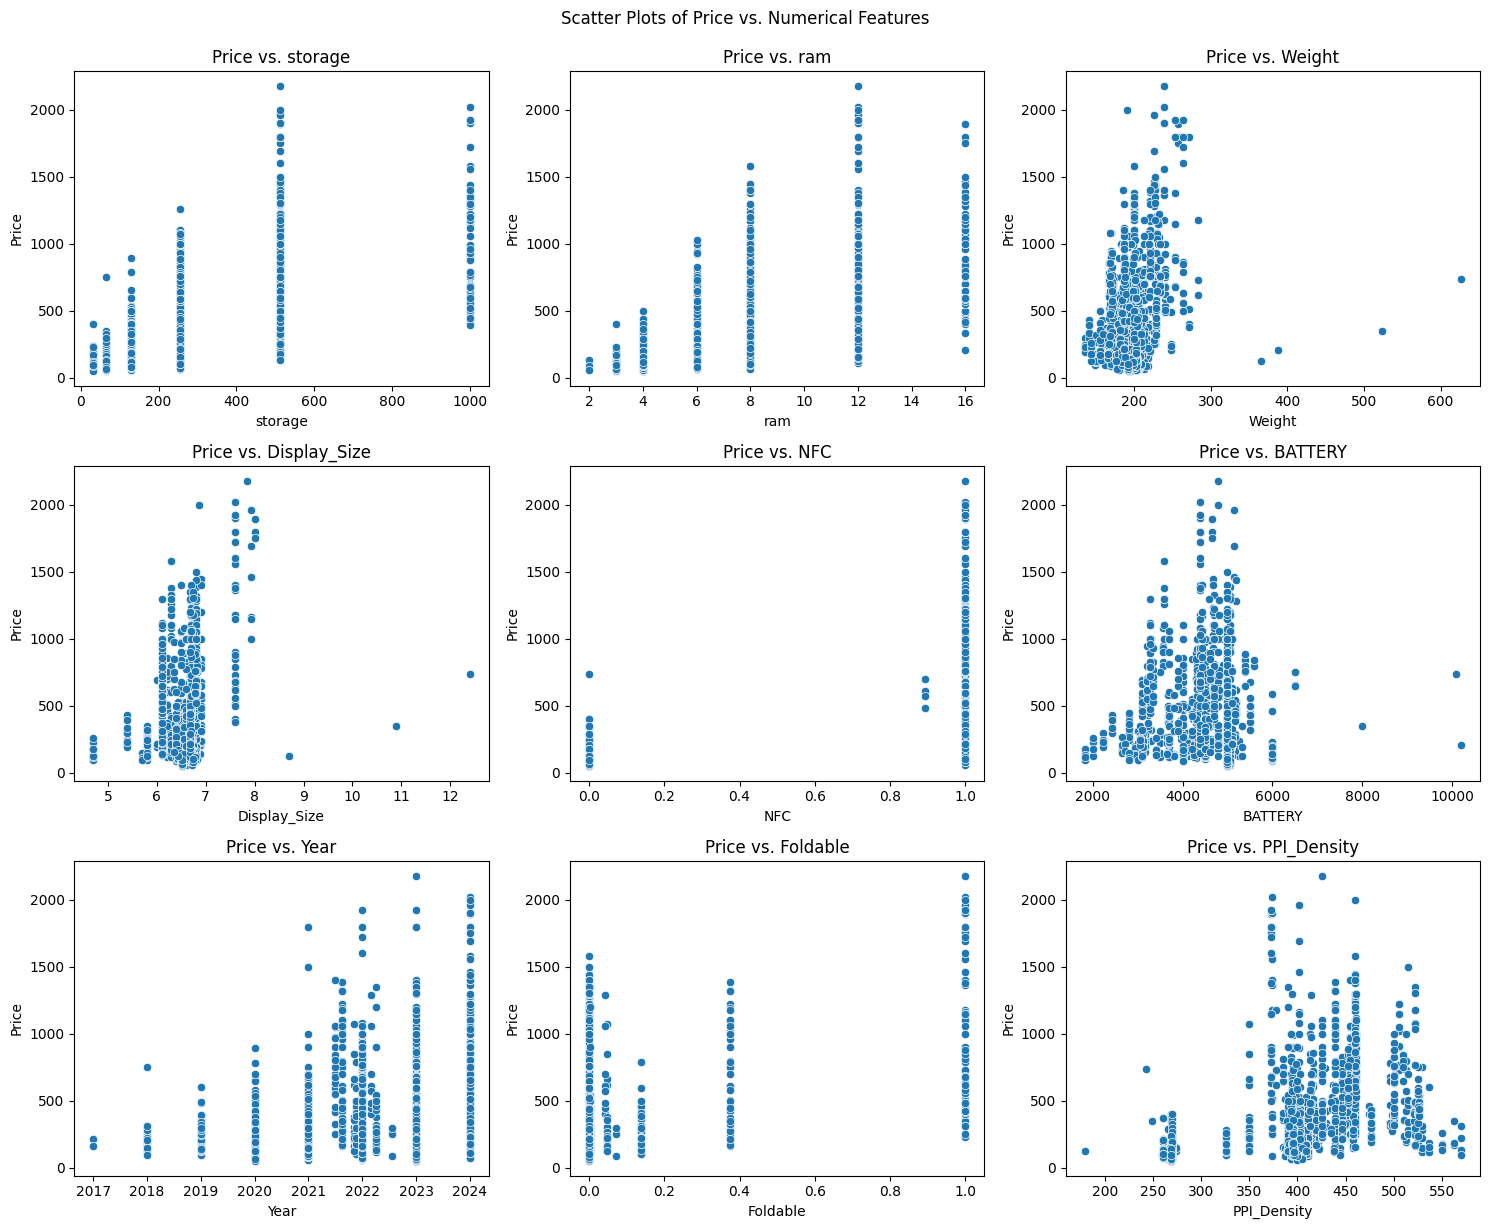

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Get numerical columns, excluding 'price' itself
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('price', errors='ignore')

# Configure subplots
n_cols = 3  # Number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(n_cols * 5, n_rows * 4))

# Plot scatter plots for 'price' vs. each numerical feature
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'Price vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Price')

plt.tight_layout()
plt.suptitle('Scatter Plots of Price vs. Numerical Features', y=1.02) # Add overall title
plt.show()

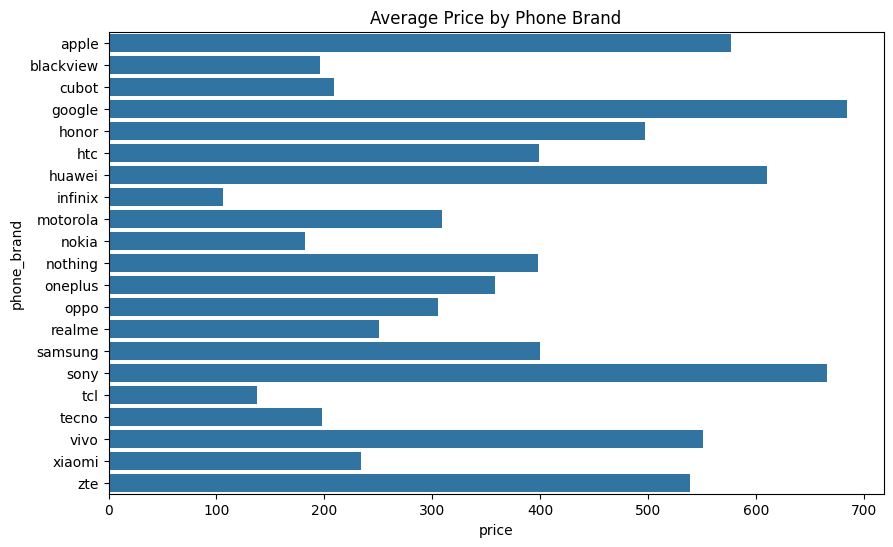

In [222]:
import seaborn as sns
import matplotlib.pyplot as plt

brand_price = df.groupby('phone_brand')['price'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=brand_price, x='price', y='phone_brand')

plt.title("Average Price by Phone Brand")
plt.show()

<Axes: xlabel='Performance', ylabel='price'>

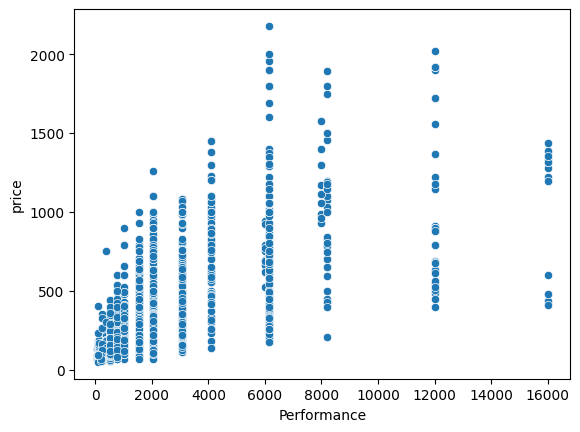

In [223]:
df['Performance'] = df['ram'] * df['storage']

sns.scatterplot(x=df['Performance'], y=df['price'])

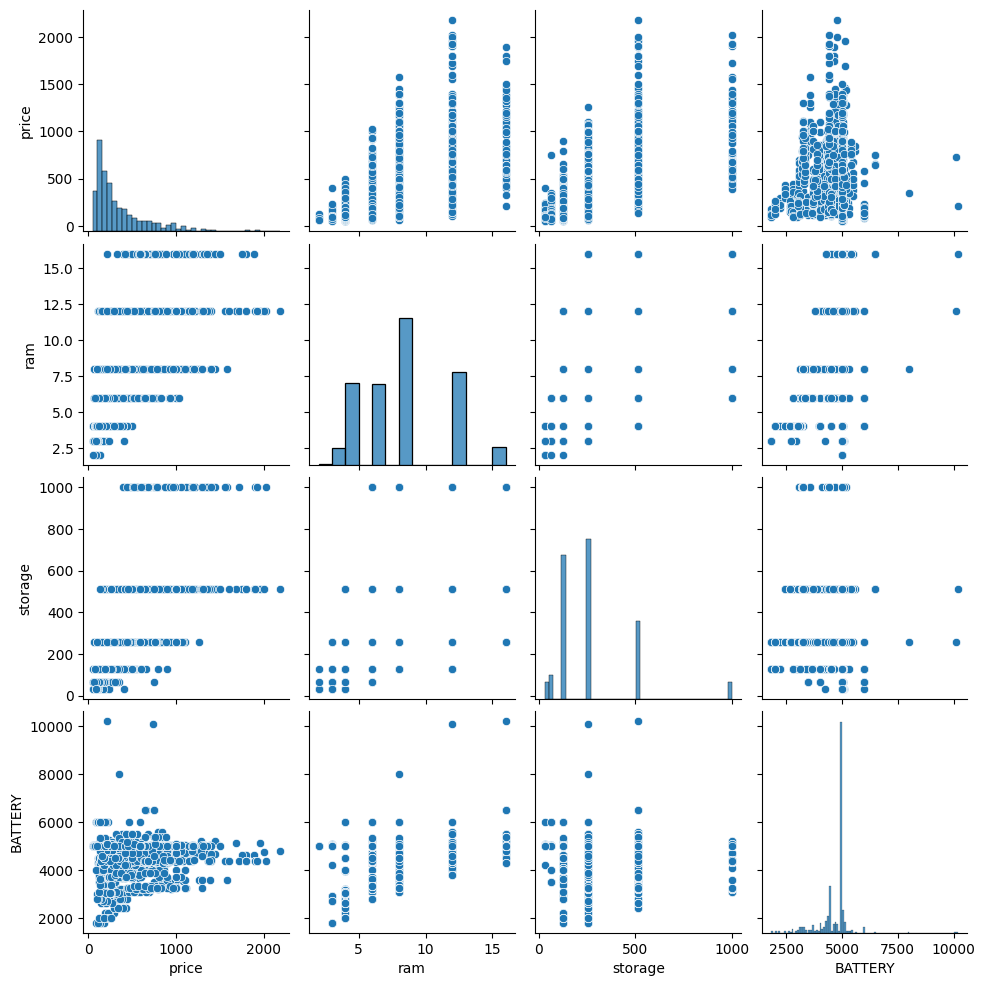

In [224]:
sns.pairplot(df[['price', 'ram', 'storage', 'BATTERY']])

# CHƯƠNG 5: MÔ HÌNH HÓA DỮ LIỆU

#5.1. Chia dữ liệu

In [225]:
X = pd.get_dummies(X, drop_first=True)

In [226]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print('Train_size:', X_train.shape)
print('Test_size:', X_test.shape)

Train_size: (1178, 1935)
Test_size: (506, 1935)


#5.2. Linear Regression

In [227]:
from sklearn.linear_model import LinearRegression

# Drop the 'Launch' column from X_train and X_test, as it's a datetime object and not suitable for Linear Regression
X_train_processed = X_train.drop(columns=['Launch'], errors='ignore')
X_test_processed = X_test.drop(columns=['Launch'], errors='ignore')

#Huấn luyện
lr = LinearRegression()
lr.fit(X_train_processed, y_train)
# Dự đoán
y_pred_lr = lr.predict(X_test_processed)

In [228]:
#Đánh giá mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print("--- Test Set Metrics ---")
mae_test = mean_absolute_error(y_test, y_pred_lr)
rmse_test = root_mean_squared_error(y_test, y_pred_lr)
r2_test = r2_score(y_test, y_pred_lr)

print("MAE (Test):", mae_test)
print("RMSE (Test):", rmse_test)
print("R2 (Test):", r2_test)

# Dự đoán trên tập huấn luyện
y_pred_train = lr.predict(X_train_processed)

print("\n--- Train Set Metrics ---")
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = root_mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print("MAE (Train):", mae_train)
print("RMSE (Train):", rmse_train)
print("R2 (Train):", r2_train)

--- Test Set Metrics ---
MAE (Test): 94.60225987472562
RMSE (Test): 149.5861496770917
R2 (Test): 0.7639607269568092

--- Train Set Metrics ---
MAE (Train): 57.379311876787156
RMSE (Train): 95.11492676059075
R2 (Train): 0.923143660799546


In [229]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': X_train_processed.columns,
    'Coefficient': lr.coef_
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print(coefficients)

                                               Feature  Coefficient
32                                      store_Best Buy   388.895359
35                                       store_Samsung   361.008567
33                                      store_Motorola   283.433809
7                                             Foldable   198.020589
524  Display_Type_Foldable LTPO AMOLED, 1B colors, ...   177.846281
..                                                 ...          ...
724                     Display_Resolution_1440 x 3168  -111.330360
404  Dimensions_254.3 x 165.8 x 6.5 mm (10.01 x 6.5...  -113.254493
719                     Display_Resolution_1440 x 2304  -113.254493
689                     Display_Resolution_1080 x 2640  -117.455324
516  Display_Type_Foldable Dynamic AMOLED 2X, 120Hz...  -118.197706

[1935 rows x 2 columns]


In [230]:
#  So sánh giá trị thực tế và giá trị dự báo ---
data = y_test.copy()
data = pd.DataFrame(data)
data["pred"] = y_pred_lr
# Tính toán phần dư (Residual = Giá thực tế - Giá dự báo)
data["residual"] = data["price"] - data["pred"]
data.head()

,price,pred,residual
1216,199.00,300.972315,-101.972315
1184,127.89,318.627134,-190.737134
578,64.95,-61.882990,126.832990
51,149.98,140.875851,9.104149
1551,154.50,131.764580,22.735420


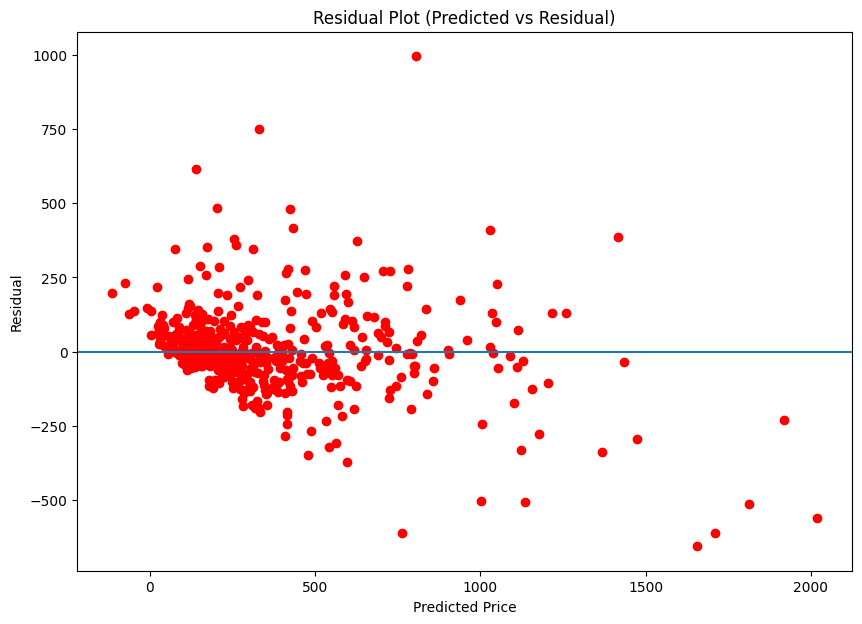

In [231]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(data["pred"], data["residual"], color="red")

# Đường y = 0
plt.axhline(y=0)

plt.title("Residual Plot (Predicted vs Residual)")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

#5.3. Decision Tree

In [232]:
from sklearn.tree import DecisionTreeRegressor

# Drop the 'Launch' column from X_train and X_test, as it's a datetime object and not suitable for Decision Tree Regressor
X_train_processed_dt = X_train.drop(columns=['Launch'], errors='ignore')
X_test_processed_dt = X_test.drop(columns=['Launch'], errors='ignore')

# Huấn luyện mô hình Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_processed_dt, y_train)

# Dự đoán trên tập kiểm tra
y_pred_dt = dt.predict(X_test_processed_dt)


In [233]:
# Đánh giá mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print("--- Test Set Metrics (Decision Tree) ---")
mae_test_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_test_dt = root_mean_squared_error(y_test, y_pred_dt)
r2_test_dt = r2_score(y_test, y_pred_dt)

print("MAE (Test):", mae_test_dt)
print("RMSE (Test):", rmse_test_dt)
print("R2 (Test):", r2_test_dt)

# Dự đoán trên tập huấn luyện
y_pred_train_dt = dt.predict(X_train_processed_dt)

print("\n--- Train Set Metrics (Decision Tree) ---")
mae_train_dt = mean_absolute_error(y_train, y_pred_train_dt)
rmse_train_dt = root_mean_squared_error(y_train, y_pred_train_dt)
r2_train_dt = r2_score(y_train, y_pred_train_dt)

print("MAE (Train):", mae_train_dt)
print("RMSE (Train):", rmse_train_dt)
print("R2 (Train):", r2_train_dt)


--- Test Set Metrics (Decision Tree) ---
MAE (Test): 102.51743083003953
RMSE (Test): 174.22372562754333
R2 (Test): 0.6798038585124495

--- Train Set Metrics (Decision Tree) ---
MAE (Train): 0.0
RMSE (Train): 0.0
R2 (Train): 1.0


In [234]:
# So sánh giá trị thực tế và giá trị dự báo cho Decision Tree
data_dt = y_test.copy()
data_dt = pd.DataFrame(data_dt)
data_dt["pred"] = y_pred_dt
# Tính toán phần dư (Residual = Giá thực tế - Giá dự báo)
data_dt["residual"] = data_dt["price"] - data_dt["pred"]
data_dt.head()

,price,pred,residual
1216,199.00,233.53,-34.53
1184,127.89,204.99,-77.10
578,64.95,56.87,8.08
51,149.98,121.27,28.71
1551,154.50,268.00,-113.50


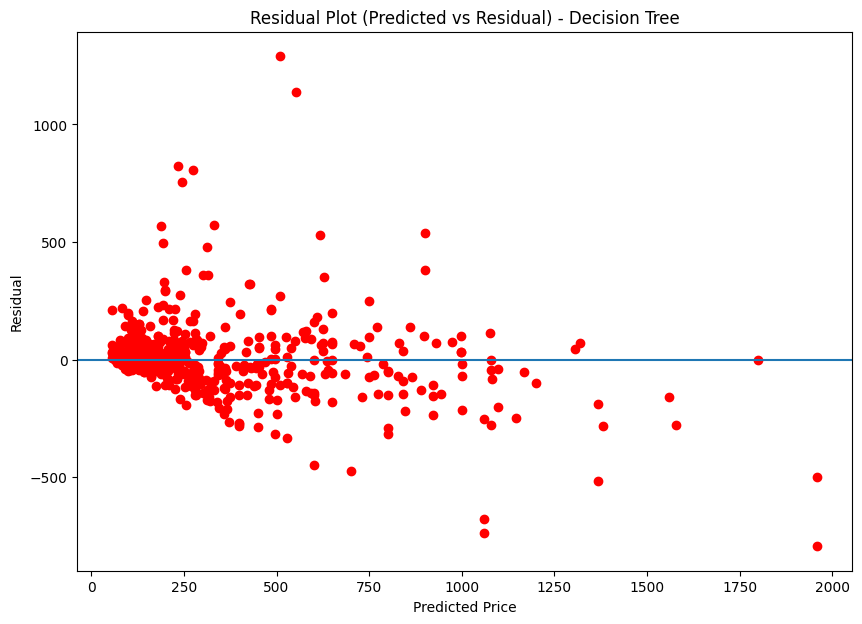

In [235]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(data_dt["pred"], data_dt["residual"], color="red")

# Đường y = 0
plt.axhline(y=0)

plt.title("Residual Plot (Predicted vs Residual) - Decision Tree")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

#5.4. Random Forest

In [236]:
from sklearn.ensemble import RandomForestRegressor

# Khởi tạo mô hình Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Huấn luyện mô hình
rf.fit(X_train_processed_dt, y_train)

# Dự đoán trên tập kiểm tra
y_pred_rf = rf.predict(X_test_processed_dt)


In [237]:
# Đánh giá mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print("--- Test Set Metrics (Random Forest) ---")
mae_test_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_test_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_test_rf = r2_score(y_test, y_pred_rf)

print("MAE (Test):", mae_test_rf)
print("RMSE (Test):", rmse_test_rf)
print("R2 (Test):", r2_test_rf)

# Dự đoán trên tập huấn luyện
y_pred_train_rf = rf.predict(X_train_processed_dt)

print("\n--- Train Set Metrics (Random Forest) ---")
mae_train_rf = mean_absolute_error(y_train, y_pred_train_rf)
rmse_train_rf = root_mean_squared_error(y_train, y_pred_train_rf)
r2_train_rf = r2_score(y_train, y_pred_train_rf)

print("MAE (Train):", mae_train_rf)
print("RMSE (Train):", rmse_train_rf)
print("R2 (Train):", r2_train_rf)


--- Test Set Metrics (Random Forest) ---
MAE (Test): 80.73467312252966
RMSE (Test): 129.29873787249235
R2 (Test): 0.8236440680280113

--- Train Set Metrics (Random Forest) ---
MAE (Train): 34.367453735144295
RMSE (Train): 56.21922202243177
R2 (Train): 0.9731495232322465


In [238]:
# So sánh giá trị thực tế và giá trị dự báo cho Random Forest
data_rf = y_test.copy()
data_rf = pd.DataFrame(data_rf)
data_rf["pred"] = y_pred_rf
# Tính toán phần dư (Residual = Giá thực tế - Giá dự báo)
data_rf["residual"] = data_rf["price"] - data_rf["pred"]
data_rf.head()

,price,pred,residual
1216,199.00,375.0665,-176.0665
1184,127.89,249.3487,-121.4587
578,64.95,135.4007,-70.4507
51,149.98,125.1829,24.7971
1551,154.50,158.1004,-3.6004


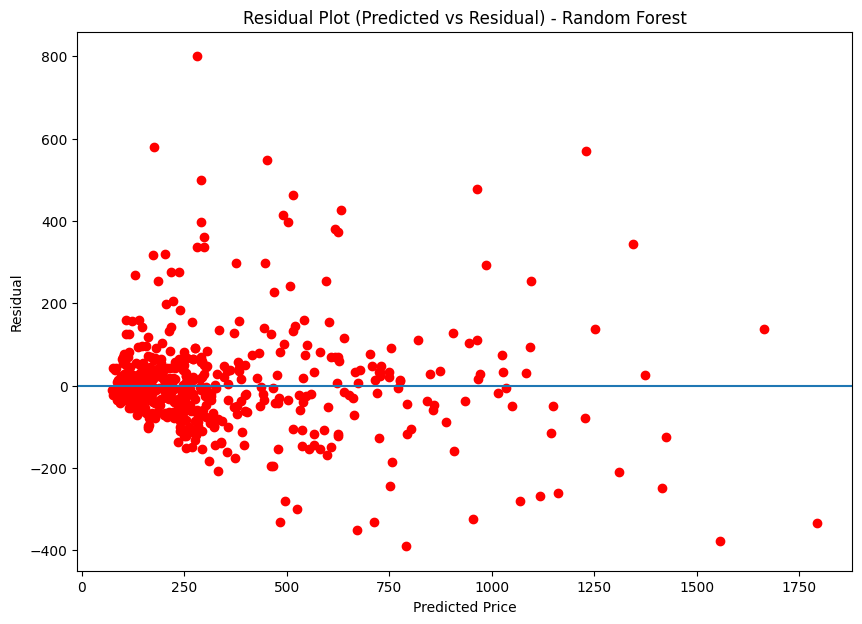

In [239]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(data_rf["pred"], data_rf["residual"], color="red")

# Đường y = 0
plt.axhline(y=0)

plt.title("Residual Plot (Predicted vs Residual) - Random Forest")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

# 5.5. XGBoost Regressor

In [244]:
from xgboost import XGBRegressor

# Khởi tạo mô hình XGBoost Regressor
# random_state được đặt để đảm bảo kết quả có thể tái lập
xgb = XGBRegressor(random_state=42)

# Huấn luyện mô hình XGBoost
xgb.fit(X_train_processed_dt, y_train)

# Dự đoán trên tập kiểm tra
y_pred_xgb = xgb.predict(X_test_processed_dt)

In [245]:
# Đánh giá mô hình
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

print("--- Test Set Metrics (XGBoost Regressor) ---")
mae_test_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_test_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_test_xgb = r2_score(y_test, y_pred_xgb)

print("MAE (Test):", mae_test_xgb)
print("RMSE (Test):", rmse_test_xgb)
print("R2 (Test):", r2_test_xgb)

# Dự đoán trên tập huấn luyện
y_pred_train_xgb = xgb.predict(X_train_processed_dt)

print("\n--- Train Set Metrics (XGBoost Regressor) ---")
mae_train_xgb = mean_absolute_error(y_train, y_pred_train_xgb)
rmse_train_xgb = root_mean_squared_error(y_train, y_pred_train_xgb)
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

print("MAE (Train):", mae_train_xgb)
print("RMSE (Train):", rmse_train_xgb)
print("R2 (Train):", r2_train_xgb)

--- Test Set Metrics (XGBoost Regressor) ---
MAE (Test): 74.29935853679191
RMSE (Test): 121.59817433446058
R2 (Test): 0.8440247788171661

--- Train Set Metrics (XGBoost Regressor) ---
MAE (Train): 33.90931114468793
RMSE (Train): 47.35847229170328
R2 (Train): 0.980946370881577


In [246]:
# So sánh giá trị thực tế và giá trị dự báo cho XGBoost Regressor
data_xgb = y_test.copy()
data_xgb = pd.DataFrame(data_xgb)
data_xgb["pred"] = y_pred_xgb
# Tính toán phần dư (Residual = Giá thực tế - Giá dự báo)
data_xgb["residual"] = data_xgb["price"] - data_xgb["pred"]
data_xgb.head()

,price,pred,residual
1216,199.00,386.830292,-187.830292
1184,127.89,234.908340,-107.018340
578,64.95,152.997711,-88.047711
51,149.98,167.697571,-17.717571
1551,154.50,156.480347,-1.980347


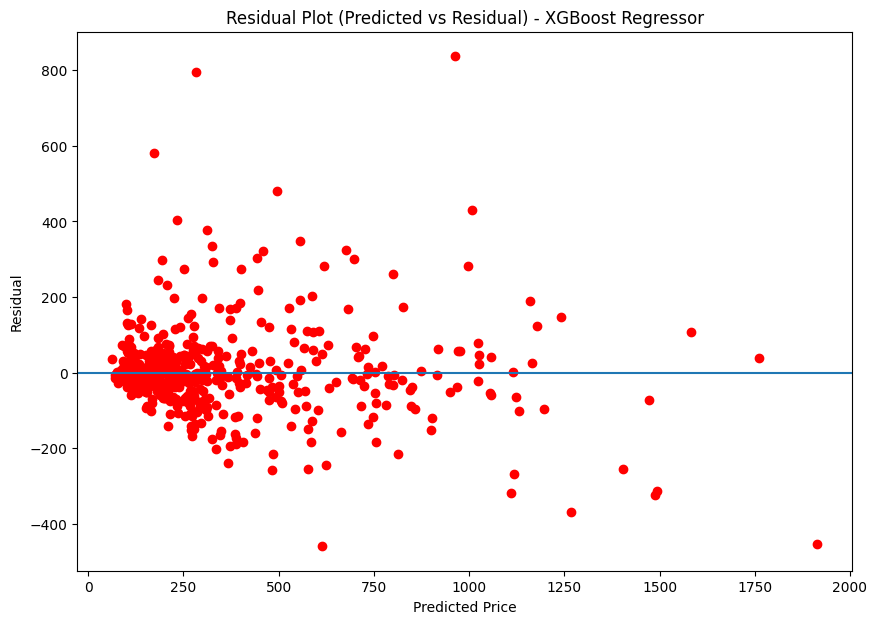

In [247]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(data_xgb["pred"], data_xgb["residual"], color="red")

# Đường y = 0
plt.axhline(y=0)

plt.title("Residual Plot (Predicted vs Residual) - XGBoost Regressor")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

<Figure size 1200x800 with 0 Axes>

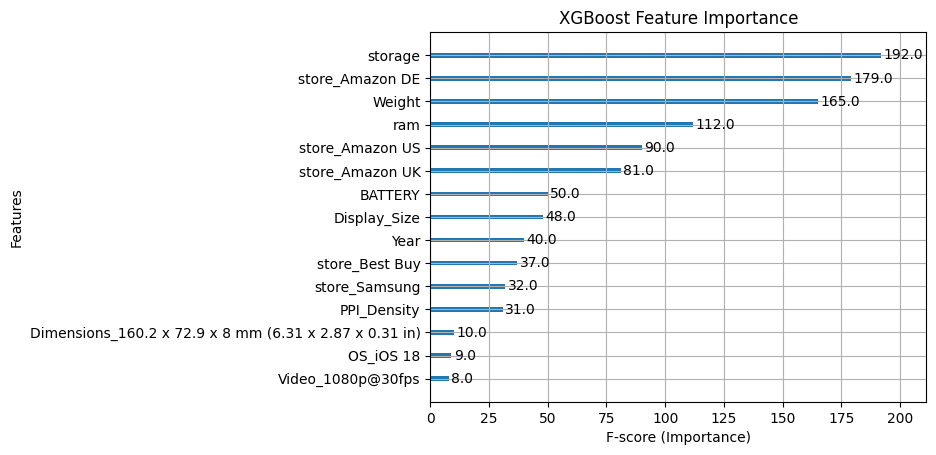

In [249]:
## Trực quan hóa tầm quan trọng của đặc trưng (Feature Importance) cho mô hình XGBoost
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plot_importance(xgb, max_num_features=15) # Hiển thị 15 đặc trưng quan trọng nhất
plt.title("XGBoost Feature Importance")
plt.xlabel("F-score (Importance)")
plt.ylabel("Features")
plt.show()